<a href="https://colab.research.google.com/github/ArhamUsman/AI-LAB/blob/main/manual_tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Machine Learning**
-

* **Supervised Learning**
  * Classification
  * Regression

* **Unsupervised Learning**
  * Clustering
  * Association
  * Dimensionality Reduction

* **Reinforcement Learning**
  * Reward
  * Decision Process
  * Recommender Systems


**Libraries Used in ML:**
-
* **NumPy** : For numerical computations

* **Pandas** : For data manipulation and analysis
* **Matplotlib** : For data visualisation
* **Scikit-Learn** : For data pre-processing, model selection, and evaluation matrics
* **Seaborn**: Provide advanced plotting functions



**Unsupervised Learning**
-

* **Kth algorithm**:
  * Step 1: Select no K
  * Step 2: Select random K points
  * Step 3: Assign each data point to nearest centroid
  * Step 4:
  * Step 5:
  * Step 6:  
  * Step 7:

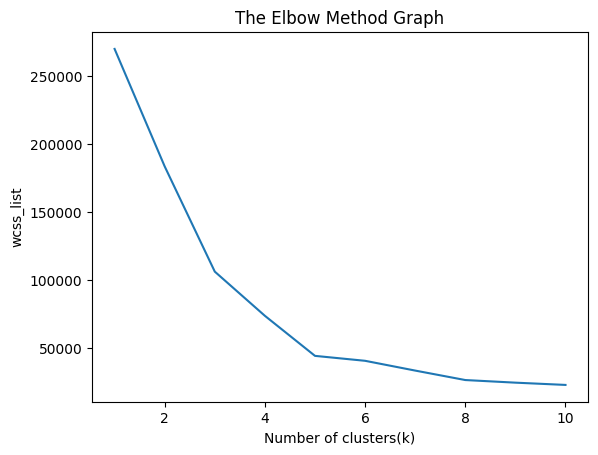

In [ ]:
#importing libraries
import numpy as nm
import matplotlib.pyplot as mtp
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Importing the dataset
# Please update the path to your 'Mall_Customers.csv' file in Google Drive
df = pd.read_csv("/content/drive/MyDrive/Mall_Customers.csv") # Example path, update as needed
df.head()
# Extracting Variables
x = df.iloc[:, [3, 4]].values
#finding optimal number of clusters using the elbow method
from sklearn.cluster import KMeans
wcss_list= [] #Initializing the list for the values of WCSS
#Using for loop for iterations from 1 to 10.
for i in range(1, 11):
  kmeans = KMeans(n_clusters=i, init="k-means++", random_state= 42)
  kmeans.fit(x)
  wcss_list.append(kmeans.inertia_)
mtp.plot(range(1, 11), wcss_list)
mtp.title("The Elbow Method Graph")
mtp.xlabel("Number of clusters(k)")
mtp.ylabel("wcss_list")
mtp.show()

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

# 1. Setup Data
data = {
    'sq_ft': [1500, 2000, 2400, 1200, 3000, 1800],
    'bedrooms': [3, 3, 4, 2, 5, 3],
    'bathrooms': [2, 2.5, 3, 1, 4, 2],
    'age': [10, 5, 2, 20, 1, 15],
    'neighborhood': ['Suburbs', 'Downtown', 'Downtown', 'Suburbs', 'Luxury', 'Suburbs'],
    'price': [300000, 450000, 500000, 200000, 850000, 320000]
}
df = pd.DataFrame(data)

# 2. Preprocessing
# One-hot encode the neighborhood
df = pd.get_dummies(df, columns=['neighborhood'])

# 3. Model Training
X = df.drop('price', axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBRegressor(n_estimators=100, learning_rate=0.1)
model.fit(X_train, y_train)

# 4. Evaluation & Prediction
preds = model.predict(X_test)
print(f"House Price R2 Score: {r2_score(y_test, preds)}")
print(f"Prediction for new house: ${model.predict(X_test.iloc[[0]])[0]:,.2f}")

House Price R2 Score: -1.3533480167388916
Prediction for new house: $201,635.70


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report

# 1. Setup Data
emails = [
    "Win a free iPhone now! Click here",
    "Meeting scheduled for tomorrow at 10am",
    "Cheap pharmacy meds no prescription",
    "Please find the attached invoice for your services",
    "URGENT: Your account has been compromised"
]
labels = [1, 0, 1, 0, 1] # 1=Spam, 0=Not Spam

# 2. Build Pipeline (Vectorization + Model)
model = make_pipeline(TfidfVectorizer(), MultinomialNB())

# 3. Train
model.fit(emails, labels)

# 4. Predict new incoming email
new_email = ["Hey, are we still on for lunch?"]
prediction = model.predict(new_email)
print(f"Email Classification (1=Spam): {prediction[0]}")

Email Classification (1=Spam): 0


In [3]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.preprocessing import StandardScaler

# 1. Setup Data
# Features: [Total Spending, Visits, Age]
X = np.array([
    [5000, 20, 35], [4500, 18, 40], [100, 1, 19],
    [200, 2, 22], [6000, 25, 45], [50, 1, 21]
])
y = np.array([1, 1, 0, 0, 1, 0]) # 1=High Value, 0=Low Value

# 2. Scaling (Important for SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. SVM for Hyperplane
svm_model = SVC(kernel='linear')
svm_model.fit(X_scaled, y)
print(f"SVM Hyperplane Coefficients: {svm_model.coef_}")

# 4. Decision Tree for Rules
tree_model = DecisionTreeClassifier(max_depth=2)
tree_model.fit(X, y) # Original units are better for readable rules

tree_rules = export_text(tree_model, feature_names=['Spending', 'Visits', 'Age'])
print("\nGenerated Classification Rules:")
print(tree_rules)

SVM Hyperplane Coefficients: [[0.43684796 0.41679122 0.33990615]]

Generated Classification Rules:
|--- Spending <= 2350.00
|   |--- class: 0
|--- Spending >  2350.00
|   |--- class: 1



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Prepare Data
data = {
    'vehicle_serial_no': [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
    'mileage': [150000, 120000, 250000, 80000, 100000, 220000, 180000, 300000, 75000, 280000],
    'fuel_efficiency': [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
    'maintenance_cost': [5000, 4000, 7000, 2000, 3000, 6500, 5500, 8000, 1500, 7500],
    'vehicle_type': ['SUV', 'Sedan', 'Truck', 'Hatchback', 'Sedan', 'Truck', 'SUV', 'Truck', 'Hatchback', 'SUV']
}
df = pd.DataFrame(data)

# Features to use (Exclude serial number and categorical type)
features = ['mileage', 'fuel_efficiency', 'maintenance_cost']
X = df[features]

# --- PART A: Without Scaling ---
kmeans_raw = KMeans(n_clusters=3, random_state=42)
df['cluster_no_scaling'] = kmeans_raw.fit_predict(X)

# --- PART B: With Scaling ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans_scaled = KMeans(n_clusters=3, random_state=42)
df['cluster_with_scaling'] = kmeans_scaled.fit_predict(X_scaled)

print(df[['vehicle_type', 'cluster_no_scaling', 'cluster_with_scaling']])

  vehicle_type  cluster_no_scaling  cluster_with_scaling
0          SUV                   2                     2
1        Sedan                   2                     2
2        Truck                   1                     1
3    Hatchback                   0                     0
4        Sedan                   0                     0
5        Truck                   1                     1
6          SUV                   2                     2
7        Truck                   1                     1
8    Hatchback                   0                     0
9          SUV                   1                     1


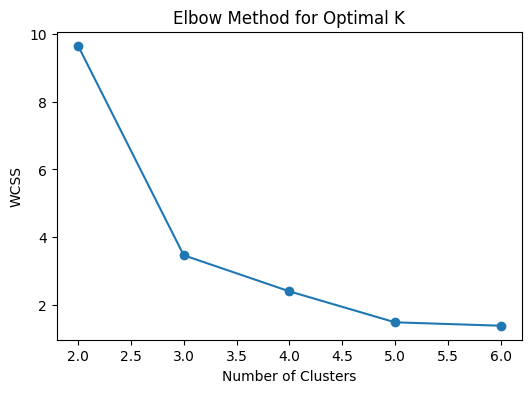

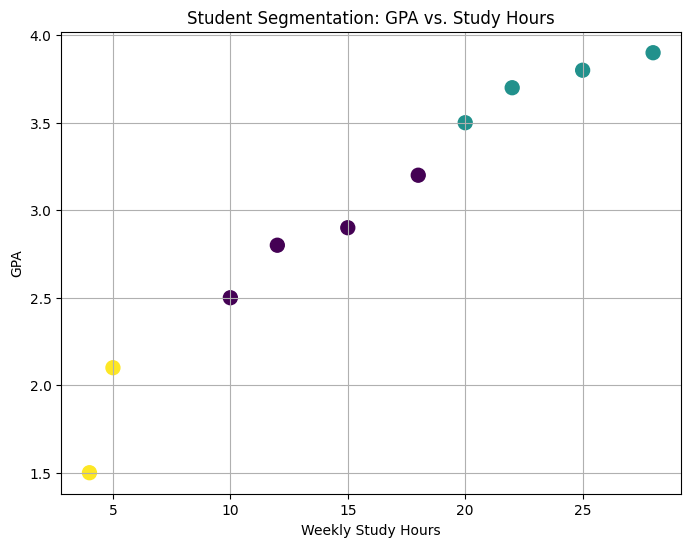

   student_id  GPA  study_hours  Cluster
0         101  3.8           25        1
1         102  2.1            5        2
2         103  3.5           20        1
3         104  2.8           12        0
4         105  3.9           28        1
5         106  1.5            4        2
6         107  3.2           18        0
7         108  2.5           10        0
8         109  3.7           22        1
9         110  2.9           15        0


In [5]:
# Sample Student Data
student_data = {
    'student_id': range(101, 111),
    'GPA': [3.8, 2.1, 3.5, 2.8, 3.9, 1.5, 3.2, 2.5, 3.7, 2.9],
    'study_hours': [25, 5, 20, 12, 28, 4, 18, 10, 22, 15],
    'attendance_rate': [95, 60, 85, 75, 98, 40, 80, 70, 90, 78]
}
student_df = pd.DataFrame(student_data)
X_students = student_df[['GPA', 'study_hours', 'attendance_rate']]

# 1. Scaling
scaler = StandardScaler()
X_stud_scaled = scaler.fit_transform(X_students)

# 2. Elbow Method
wcss = [] # Within-Cluster Sum of Square
for i in range(2, 7):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_stud_scaled)
    wcss.append(kmeans.inertia_)

# Visualization of Elbow
plt.figure(figsize=(6,4))
plt.plot(range(2, 7), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# 3. Apply K-Means (Assuming Elbow is at K=3)
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
student_df['Cluster'] = kmeans_final.fit_predict(X_stud_scaled)

# 4. Visualize Clusters (GPA vs Study Hours)
plt.figure(figsize=(8,6))
plt.scatter(student_df['study_hours'], student_df['GPA'], c=student_df['Cluster'], cmap='viridis', s=100)
plt.title('Student Segmentation: GPA vs. Study Hours')
plt.xlabel('Weekly Study Hours')
plt.ylabel('GPA')
plt.grid(True)
plt.show()

print(student_df[['student_id', 'GPA', 'study_hours', 'Cluster']])